## Overview
This notebook regresses a portfolio of 3 tickers against a two-factor model (Market + HML) and compares three portfolio strategies: Naive MVO, Ridge MVO and Factor Neutral.

- Tickers: `["GLD", "QQQ", "SOXX", "TLT"]`
- Risk-free rate: `^IRX` (CBOE 13-week Treasury yield)
- Data period: 10 years requested (`365 * 10` days).

``` text
Group Members:
    Chew Junhong
    Marcus Tan Jun Lin
    Chia Chong Yee
    Abirame d/o Asohan
    Ramona Chia
```
_Prepared with the assistance of Claude (Anthropic) for code review and slide drafting. All results were checked by the group._

## 1. SET UP LIBRARIES

In [35]:
import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt
from plotnine import (
    ggplot, aes, geom_line, geom_point, geom_hline, geom_tile, geom_text,
    facet_wrap, scale_color_manual, scale_linetype_manual,
    scale_fill_gradient2, scale_y_log10, scale_x_date, scale_x_discrete, scale_y_discrete,
    labs, theme, element_text, coord_equal
)

from IPython.display import Markdown, display
from scipy import stats

## 2. INPUT PARAMETERS

In [36]:
# Portfolio specified in the new project requirements
tickers = ["GLD", "QQQ", "SOXX", "TLT"]

# Risk-free rate
rf_ticker = "^IRX"

# Define the data period by number of days OR by a specific start date.
# We use PERIOD here.
period = 365 * 10

# Leave START as None because PERIOD is being used.
start = None

if period is not None:
    start = dt.datetime.now() - dt.timedelta(days=period)

print("Period:", period, "days")
print("Start:", start)

Period: 3650 days
Start: 2016-10-01 22:20:06.188364


## 3. CONSTANT PARAMETERS

In [37]:
trading_days = 252

# Risk-aversion parameter
lam = 1.0

# Expected-return perturbation:
# 1 basis point = 0.0001
nudge = 0.01

print("Trading days:", trading_days)
print("Lambda:", lam)
print("Expected-return nudge:", nudge)

Trading days: 252
Lambda: 1.0
Expected-return nudge: 0.01


## 4. DOWNLOAD DATA

In [38]:
data_tickers = [
    *tickers,
    "^GSPC",   # S&P 500 Market Index
    "IVE",     # S&P 500 Value
    "IVW",     # S&P 500 Growth
    rf_ticker  # ^IRX
]

prices = yf.download(
    data_tickers,
    start=start,
    auto_adjust=True,
    progress=False
)["Close"]

# Remove columns that contain no data
prices = prices.dropna(axis=1, how="all")

print("Data downloaded successfully.")
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Number of observations:", len(prices))

Data downloaded successfully.
Date range: 2016-10-03 00:00:00 to 2026-09-29 00:00:00
Number of observations: 2511


## 5. PREPARE RETURNS & RISK-FREE RATE

In [39]:
# Daily percentage returns
returns = prices.pct_change().dropna()

# Portfolio returns
R = returns[tickers].copy()

# ^IRX is quoted as an annualised percentage yield.
# Convert from percentage to decimal.
rf_rate = prices[rf_ticker] / 100

# Align risk-free rate with the return dates
rf_rate = rf_rate.reindex(returns.index)

# Daily risk-free rate, to match the daily returns it is subtracted from
rf_daily = rf_rate / trading_days

print("Risk-free rate prepared successfully.")
print("Daily risk-free rate:")
display(rf_daily.head())

print("\nPortfolio returns:")
display(R.head())

Risk-free rate prepared successfully.
Daily risk-free rate:


Date
2016-10-04    0.000012
2016-10-05    0.000012
2016-10-06    0.000012
2016-10-07    0.000012
2016-10-10    0.000012
Name: ^IRX, dtype: float64


Portfolio returns:


Ticker,GLD,QQQ,SOXX,TLT
Date,,,,
2016-10-04,-0.034711,-0.001518,-0.002584,-0.011695
2016-10-05,-0.001571,0.003548,0.007325,-0.004660
2016-10-06,-0.009273,-0.000505,0.005854,-0.005573
2016-10-07,0.000669,-0.002190,-0.001499,0.000673
2016-10-10,0.003508,0.006331,-0.005033,-0.005899


## 6. TWO-FACTOR MODEL

In [40]:
# Market excess return
# MKT = S&P 500 return - daily risk-free rate
returns["MKT"] = returns["^GSPC"] - rf_daily

# HML = Value - Growth
returns["HML"] = returns["IVE"] - returns["IVW"]

# Keep only the two required factors
F = returns[["MKT", "HML"]].copy()

# Align all datasets to the same dates
common_index = R.index.intersection(F.index)

R = R.loc[common_index]
F = F.loc[common_index]
rf_rate = rf_rate.loc[common_index]
rf_daily = rf_daily.loc[common_index]

print("Two-factor model constructed successfully.")

print("\nMKT and HML:")
display(F.head())

Two-factor model constructed successfully.

MKT and HML:


Ticker,MKT,HML
Date,,
2016-10-04,-0.004968,-0.001373
2016-10-05,0.004284,0.005226
2016-10-06,0.000469,-0.000537
2016-10-07,-0.003266,0.000963
2016-10-10,0.004594,-0.000130


## 7. EXPECTED RETURN VECTOR μ

Estimate mu 

In [41]:
mu = R.mean() * trading_days

print("Annualised historical mean returns:")
display(mu.to_frame("μ").round(6))

Annualised historical mean returns:


,μ
Ticker,
GLD,0.128740
QQQ,0.217241
SOXX,0.341157
TLT,-0.015418


## 8. FACTOR REGRESSIONS

In [42]:
# Store factor loadings
B = pd.DataFrame(
    index=tickers,
    columns=["MKT", "HML"],
    dtype=float
)

# Store regression alpha
alpha = pd.Series(
    index=tickers,
    dtype=float
)

# Store residuals
residuals = pd.DataFrame(
    index=R.index,
    columns=tickers,
    dtype=float
)

# Store regression statistics
regression_stats = {}

for ticker in tickers:

    # Create one dataframe containing everything needed
    regression_data = pd.concat(
        [
            R[ticker].rename("asset_return"),
            rf_daily.rename("rf"),
            F["MKT"],
            F["HML"]
        ],
        axis=1
    )

    # Remove missing or infinite observations
    regression_data = regression_data.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Excess return
    y = (
        regression_data["asset_return"]
        - regression_data["rf"]
    ).values

    # Regression factors
    X_factors = regression_data[
        ["MKT", "HML"]
    ].values

    # Add intercept
    X = np.column_stack([
        np.ones(len(X_factors)),
        X_factors
    ])

    # Check that there are enough observations
    if len(y) <= X.shape[1]:
        raise ValueError(
            f"Not enough observations to regress {ticker}."
        )

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    # Save alpha
    alpha[ticker] = coefficients[0]

    # Save factor loadings
    B.loc[ticker, "MKT"] = coefficients[1]
    B.loc[ticker, "HML"] = coefficients[2]

    # Predicted excess return
    fitted = X @ coefficients

    # Residual
    residual = y - fitted

    # Put residuals back into the original dates
    residuals.loc[
        regression_data.index,
        ticker
    ] = residual

    # R-squared
    ss_res = np.sum(
        (y - fitted) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    r_squared = 1 - ss_res / ss_tot

    regression_stats[ticker] = {
        "Observations": len(y),
        "R²": r_squared
    }


# Remove rows where residuals are missing
residuals = residuals.dropna()

alpha_annual = alpha * trading_days

print("Regression anualised alpha:")
display(alpha_annual.to_frame("Alpha").round(6))

print("\nFactor loading matrix B:")
display(B.round(6))

print("\nRegression statistics:")
display(pd.DataFrame(regression_stats).T.round(6))

Regression anualised alpha:


,Alpha
GLD,0.088945
QQQ,0.034444
SOXX,0.106922
TLT,-0.031730



Factor loading matrix B:


,MKT,HML
GLD,0.074579,-0.106054
QQQ,1.020527,-0.572277
SOXX,1.351984,-0.756617
TLT,-0.162276,-0.183618



Regression statistics:


,Observations,R²
GLD,2508.0,0.018155
QQQ,2508.0,0.956814
SOXX,2508.0,0.704331
TLT,2508.0,0.041624


## 9. FACTOR COVARIANCE Ω

In [43]:
Omega_daily = F.cov()

print("Daily factor covariance Ω:")
display(Omega_daily.round(8))

# Annualised factor covariance
Omega = Omega_daily * trading_days

print("\nAnnualised factor covariance Ω:")
display(Omega.round(6))

Daily factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.000130,-0.000032
HML,-0.000032,0.000063



Annualised factor covariance Ω:


Ticker,MKT,HML
Ticker,,
MKT,0.032701,-0.008107
HML,-0.008107,0.015958


## 10. RESIDUAL COVARIANCE D

In [44]:
D_daily = residuals.cov()

# Annualise
D = D_daily * trading_days

# Keep only the idiosyncratic variances: the factor model assumes
# residuals are uncorrelated across assets, so D is diagonal
D = pd.DataFrame(
    np.diag(np.diag(D)),
    index=D.index,
    columns=D.columns
)

print("Annualised residual covariance D:")
display(D.round(6))

Annualised residual covariance D:


,GLD,QQQ,SOXX,TLT
GLD,0.026479,0.0000,0.000000,0.000000
QQQ,0.000000,0.0022,0.000000,0.000000
SOXX,0.000000,0.0000,0.035889,0.000000
TLT,0.000000,0.0000,0.000000,0.021092


## 11. RECONSTRUCT Σ

In [45]:
B_np = B.values
Omega_np = Omega.values
D_np = D.values

Sigma = (
    B_np @ Omega_np @ B_np.T
    + D_np
)

Sigma = pd.DataFrame(
    Sigma,
    index=tickers,
    columns=tickers
)

print("Reconstructed annualised covariance matrix Σ:")
display(Sigma.round(6))

Reconstructed annualised covariance matrix Σ:


,GLD,QQQ,SOXX,TLT
GLD,0.026969,0.004681,0.006198,-0.000114
QQQ,0.004681,0.050953,0.064560,-0.002972
SOXX,0.006198,0.064560,0.121382,-0.003940
TLT,-0.000114,-0.002972,-0.003940,0.022008


## 12. Estimate the inputs and assemble equation Σ = BΩBᵀ + D

In [46]:
display(Markdown(
    r"""
    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    """
))

print("=" * 60)
print("EXPECTED RETURN VECTOR μ")
print("=" * 60)
display(mu.to_frame("Annualised μ").round(6))

print("=" * 60)
print("FACTOR LOADING MATRIX B")
print("=" * 60)
display(B.round(6))

print("=" * 60)
print("REGRESSION ALPHA")
print("=" * 60)
display(alpha.to_frame("Alpha").round(6))

print("=" * 60)
print("FACTOR COVARIANCE MATRIX Ω")
print("=" * 60)
display(Omega.round(6))

print("=" * 60)
print("RESIDUAL COVARIANCE MATRIX D")
print("=" * 60)
display(D.round(6))

print("=" * 60)
print("RECONSTRUCTED COVARIANCE MATRIX Σ")
print("=" * 60)
display(Sigma.round(6))


    ### Two-Factor Covariance Model

    The covariance matrix is reconstructed using:

    $$\Sigma = B\Omega B^{T} + D$$

    where:

    - $\Sigma$ = estimated covariance matrix of portfolio asset returns
    - $B$ = factor-loading matrix
    - $\Omega$ = factor covariance matrix
    - $D$ = residual/idiosyncratic covariance matrix
    

EXPECTED RETURN VECTOR μ


,Annualised μ
Ticker,
GLD,0.128740
QQQ,0.217241
SOXX,0.341157
TLT,-0.015418


FACTOR LOADING MATRIX B


,MKT,HML
GLD,0.074579,-0.106054
QQQ,1.020527,-0.572277
SOXX,1.351984,-0.756617
TLT,-0.162276,-0.183618


...

Ticker,MKT,HML
Ticker,,
MKT,0.032701,-0.008107
HML,-0.008107,0.015958


RESIDUAL COVARIANCE MATRIX D


,GLD,QQQ,SOXX,TLT
GLD,0.026479,0.0000,0.000000,0.000000
QQQ,0.000000,0.0022,0.000000,0.000000
SOXX,0.000000,0.0000,0.035889,0.000000
TLT,0.000000,0.0000,0.000000,0.021092


RECONSTRUCTED COVARIANCE MATRIX Σ


,GLD,QQQ,SOXX,TLT
GLD,0.026969,0.004681,0.006198,-0.000114
QQQ,0.004681,0.050953,0.064560,-0.002972
SOXX,0.006198,0.064560,0.121382,-0.003940
TLT,-0.000114,-0.002972,-0.003940,0.022008


## 13. NAIVE MVO

In [47]:
Sigma_np = Sigma.values
mu_np = mu.values
n = len(tickers)

w_naive = pd.Series(
    np.linalg.solve(lam * Sigma_np, mu_np), index=tickers, name="Naive MVO"
)
print("Naive MVO weights:")
display(w_naive.to_frame().round(6))
print("Sum of weights (rest is cash / borrowing at Rf):", w_naive.sum())
print("Gross exposure:", w_naive.abs().sum())

Naive MVO weights:


,Naive MVO
GLD,4.083443
QQQ,1.806208
SOXX,1.636808
TLT,-0.142497


Sum of weights (rest is cash / borrowing at Rf): 7.38396172506414
Gross exposure: 7.668955308379575


## 14. NAIVE MVO SENSITIVITY

In [48]:
mu_nudged = mu_np.copy()
mu_nudged[1] += nudge  # +1 percentage point on QQQ
w_naive_nudged = pd.Series(
    np.linalg.solve(lam * Sigma_np, mu_nudged), index=tickers, name="Nudged"
)
weight_swing_naive = w_naive_nudged - w_naive
turnover_naive = 0.5 * weight_swing_naive.abs().sum()

print("Original weights:")
display(w_naive.to_frame())

print("\nNudged weights (+1% QQQ):")
display(w_naive_nudged.to_frame())

print("\nWeight changes:")
display(weight_swing_naive.to_frame("Weight Change"))

print("\nL2 weight swing:",
      np.linalg.norm(weight_swing_naive))

print("Turnover:",
      turnover_naive)

Original weights:


,Naive MVO
GLD,4.083443
QQQ,1.806208
SOXX,1.636808
TLT,-0.142497



Nudged weights (+1% QQQ):


,Nudged
GLD,4.051895
QQQ,2.411989
SOXX,1.317012
TLT,-0.118098



Weight changes:


,Weight Change
GLD,-0.031548
QQQ,0.605782
SOXX,-0.319797
TLT,0.024398



L2 weight swing: 0.6861717919786217
Turnover: 0.4907621598798716


## 15. RIDGE MVO

In [49]:
etas = [0.00, 0.001, 0.005, 0.01, 0.05, 0.10, 0.50, 1.00]
ridge_results, ridge_weights = [], {}
for eta in etas:
    M = lam * Sigma_np + eta * np.eye(n)
    w_before = np.linalg.solve(M, mu_np)
    w_after = np.linalg.solve(M, mu_nudged)
    change = w_after - w_before
    ridge_weights[eta] = pd.Series(w_before, index=tickers)
    ridge_results.append(
        {
            "eta": eta,
            "weight_swing": np.linalg.norm(change),
            "turnover": 0.5 * np.abs(change).sum(),
            "gross_exposure": np.abs(w_before).sum(),
        }
    )
ridge_results = pd.DataFrame(ridge_results)
display(ridge_results.round(6))

,eta,weight_swing,turnover,gross_exposure
0,0.000,0.686172,0.490762,7.668955
1,0.001,0.635620,0.453693,7.497973
2,0.005,0.491086,0.347917,6.915459
3,0.010,0.382609,0.268794,6.350381
4,0.050,0.139641,0.093192,4.193219
5,0.100,0.078901,0.050303,3.114548
6,0.500,0.018475,0.010257,1.103248
7,1.000,0.009565,0.005082,0.616947


## 16. SELECT RIDGE PORTFOLIO

In [50]:
selected_eta = 0.10

w_ridge = ridge_weights[selected_eta].copy()
w_ridge.name = "Ridge MVO"

print(f"Selected ridge parameter η = {selected_eta}")
display(w_ridge.to_frame().round(6))

Selected ridge parameter η = 0.1


,Ridge MVO
GLD,0.920293
QQQ,0.870319
SOXX,1.260331
TLT,-0.063606


## 17. RIDGE SENSITIVITY PLOT

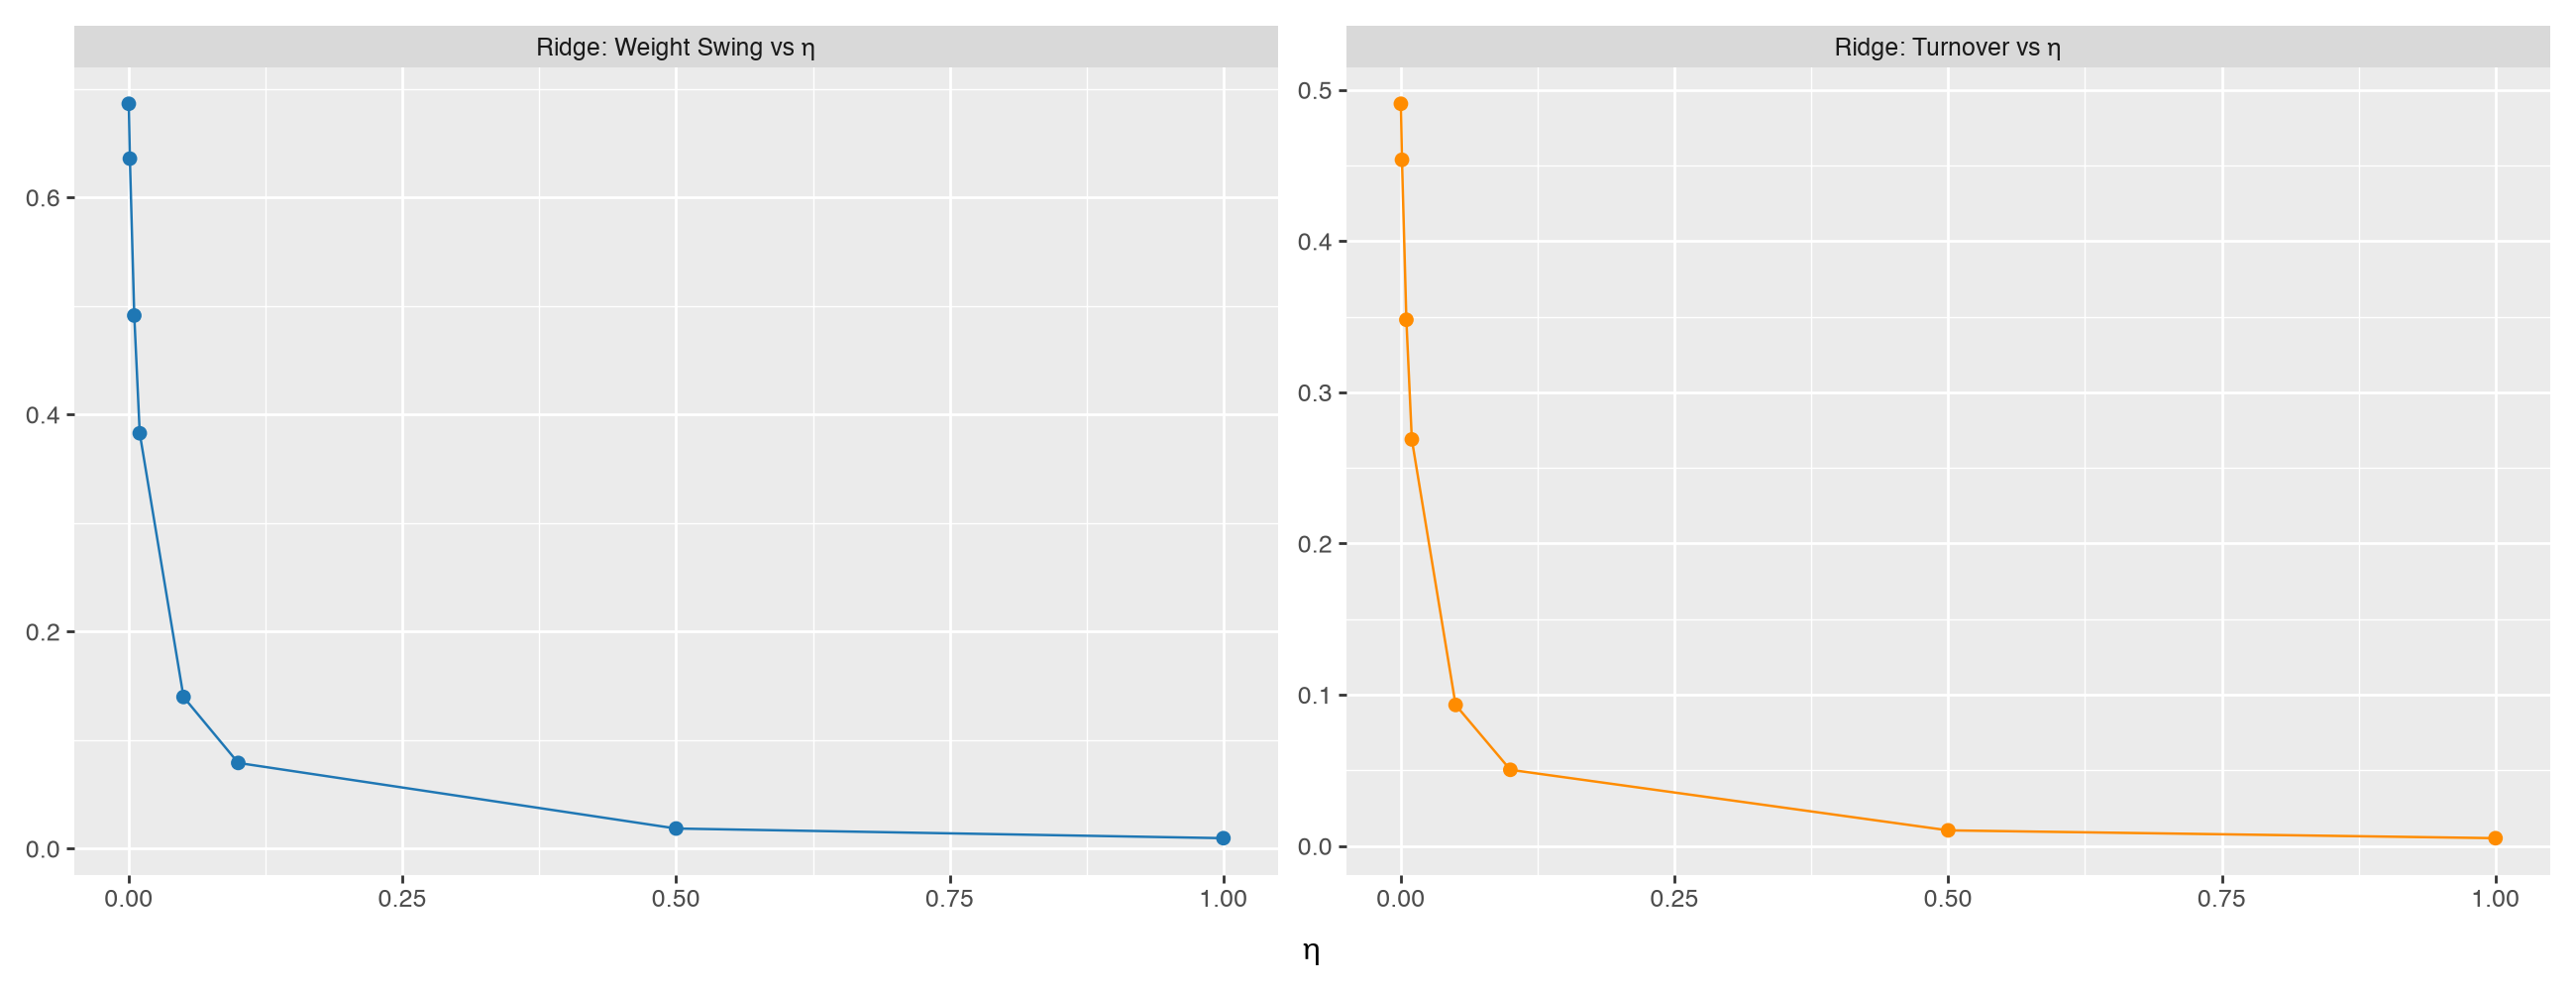

In [51]:
ridge_plot_data = ridge_results[["eta", "weight_swing", "turnover"]].melt(
    id_vars="eta",
    var_name="Metric",
    value_name="Value"
)

ridge_plot_data["Metric"] = pd.Categorical(
    ridge_plot_data["Metric"].map({
        "weight_swing": "Ridge: Weight Swing vs η",
        "turnover": "Ridge: Turnover vs η"
    }),
    categories=["Ridge: Weight Swing vs η", "Ridge: Turnover vs η"]
)

display(
    ggplot(ridge_plot_data, aes("eta", "Value", color="Metric"))
    + geom_line()
    + geom_point(size=2)
    + facet_wrap("~Metric", scales="free_y")
    + scale_color_manual(values=["#1f77b4", "darkorange"])
    + labs(x="η", y="")
    + theme(figure_size=(13, 5), legend_position="none")
)

## 18. FACTOR-NEUTRAL PORTFOLIO

In [52]:
D_np = np.asarray(D)
B_np = B.values
alpha_np = np.asarray(alpha_annual)  # annualised, same scale as D
Di = np.linalg.inv(D_np)
w0 = Di @ alpha_np / lam

# Constraints Cᵀw = d:
# 1) Fully invested: 1ᵀw = 1
# 2) MKT neutral: β_MKTᵀw = 0
# 3) HML neutral: β_HMLᵀw = 0
C = np.column_stack([np.ones(len(tickers)), B_np])
d = np.concatenate([[1.0], np.zeros(B_np.shape[1])])

# Project w0 onto the constraint set in the D⁻¹ metric
w_fn = w0 - Di @ C @ np.linalg.solve(C.T @ Di @ C, C.T @ w0 - d)
w_fn = pd.Series(w_fn, index=tickers, name="Factor Neutral")
factor_exposures_fn = B.T @ w_fn
print("Factor-neutral portfolio:")
display(w_fn.to_frame().round(6))
print("Weight sum:", w_fn.sum())
print("Factor exposures Bᵀw:")
display(factor_exposures_fn.to_frame("Exposure"))
print(
    f"Alpha: ideal w0 = {alpha_np @ w0:.2%}  ->  neutral w* = {alpha_np @ w_fn:.2%}  (price of neutrality)"
)

Factor-neutral portfolio:


,Factor Neutral
GLD,2.412790
QQQ,-2.688064
SOXX,1.829438
TLT,-0.554164


Weight sum: 0.9999999999999949
Factor exposures Bᵀw:


,Exposure
MKT,4.713046e-15
HML,-6.486680e-15


Alpha: ideal w0 = 120.42%  ->  neutral w* = 33.52%  (price of neutrality)


## 19. VERIFY FACTOR NEUTRALITY

In [53]:
print("Bᵀw:")
print(factor_exposures_fn)

print("\nMaximum absolute factor exposure:",
      np.abs(factor_exposures_fn).max())

print("Weight sum:", w_fn.sum())

assert np.isclose(w_fn.sum(), 1.0)

assert np.allclose(
    B.T @ w_fn,
    0,
    atol=1e-6
)

print("\nFully-invested and factor-neutrality constraints satisfied.")

Bᵀw:
MKT    4.713046e-15
HML   -6.486680e-15
dtype: float64

Maximum absolute factor exposure: 6.486679597057681e-15
Weight sum: 0.9999999999999949

Fully-invested and factor-neutrality constraints satisfied.


## 20. STRATEGY WEIGHTS

In [54]:
strategy_weights = pd.DataFrame({
    "Naive MVO": w_naive,
    "Ridge MVO": w_ridge,
    "Factor Neutral": w_fn
})

display(strategy_weights.round(6))

,Naive MVO,Ridge MVO,Factor Neutral
GLD,4.083443,0.920293,2.412790
QQQ,1.806208,0.870319,-2.688064
SOXX,1.636808,1.260331,1.829438
TLT,-0.142497,-0.063606,-0.554164


## 21. COMMON BENCHMARK

In [55]:
benchmark_weights = pd.Series(
    1 / n,
    index=tickers,
    name="Equal Weight Benchmark"
)

print("Benchmark weights:")
display(benchmark_weights.to_frame())

Benchmark weights:


,Equal Weight Benchmark
GLD,0.25
QQQ,0.25
SOXX,0.25
TLT,0.25


## 22. TRACKING ERROR

In [56]:
tracking_results = []

for strategy in strategy_weights.columns:

    w = strategy_weights[strategy]

    active_weights = w - benchmark_weights

    TE2 = (
        active_weights.values
        @ Sigma_np
        @ active_weights.values
    )

    TE = np.sqrt(TE2)

    tracking_results.append({
        "Portfolio": strategy,
        "TE²": TE2,
        "Tracking Error": TE
    })

TE_results = pd.DataFrame(tracking_results)

print("Ex-ante tracking error:")
display(TE_results.round(6))

Ex-ante tracking error:


,Portfolio,TE²,Tracking Error
0,Naive MVO,1.165214,1.079451
1,Ridge MVO,0.254701,0.504679
2,Factor Neutral,0.263054,0.512888


## 23. EQUITY CURVE

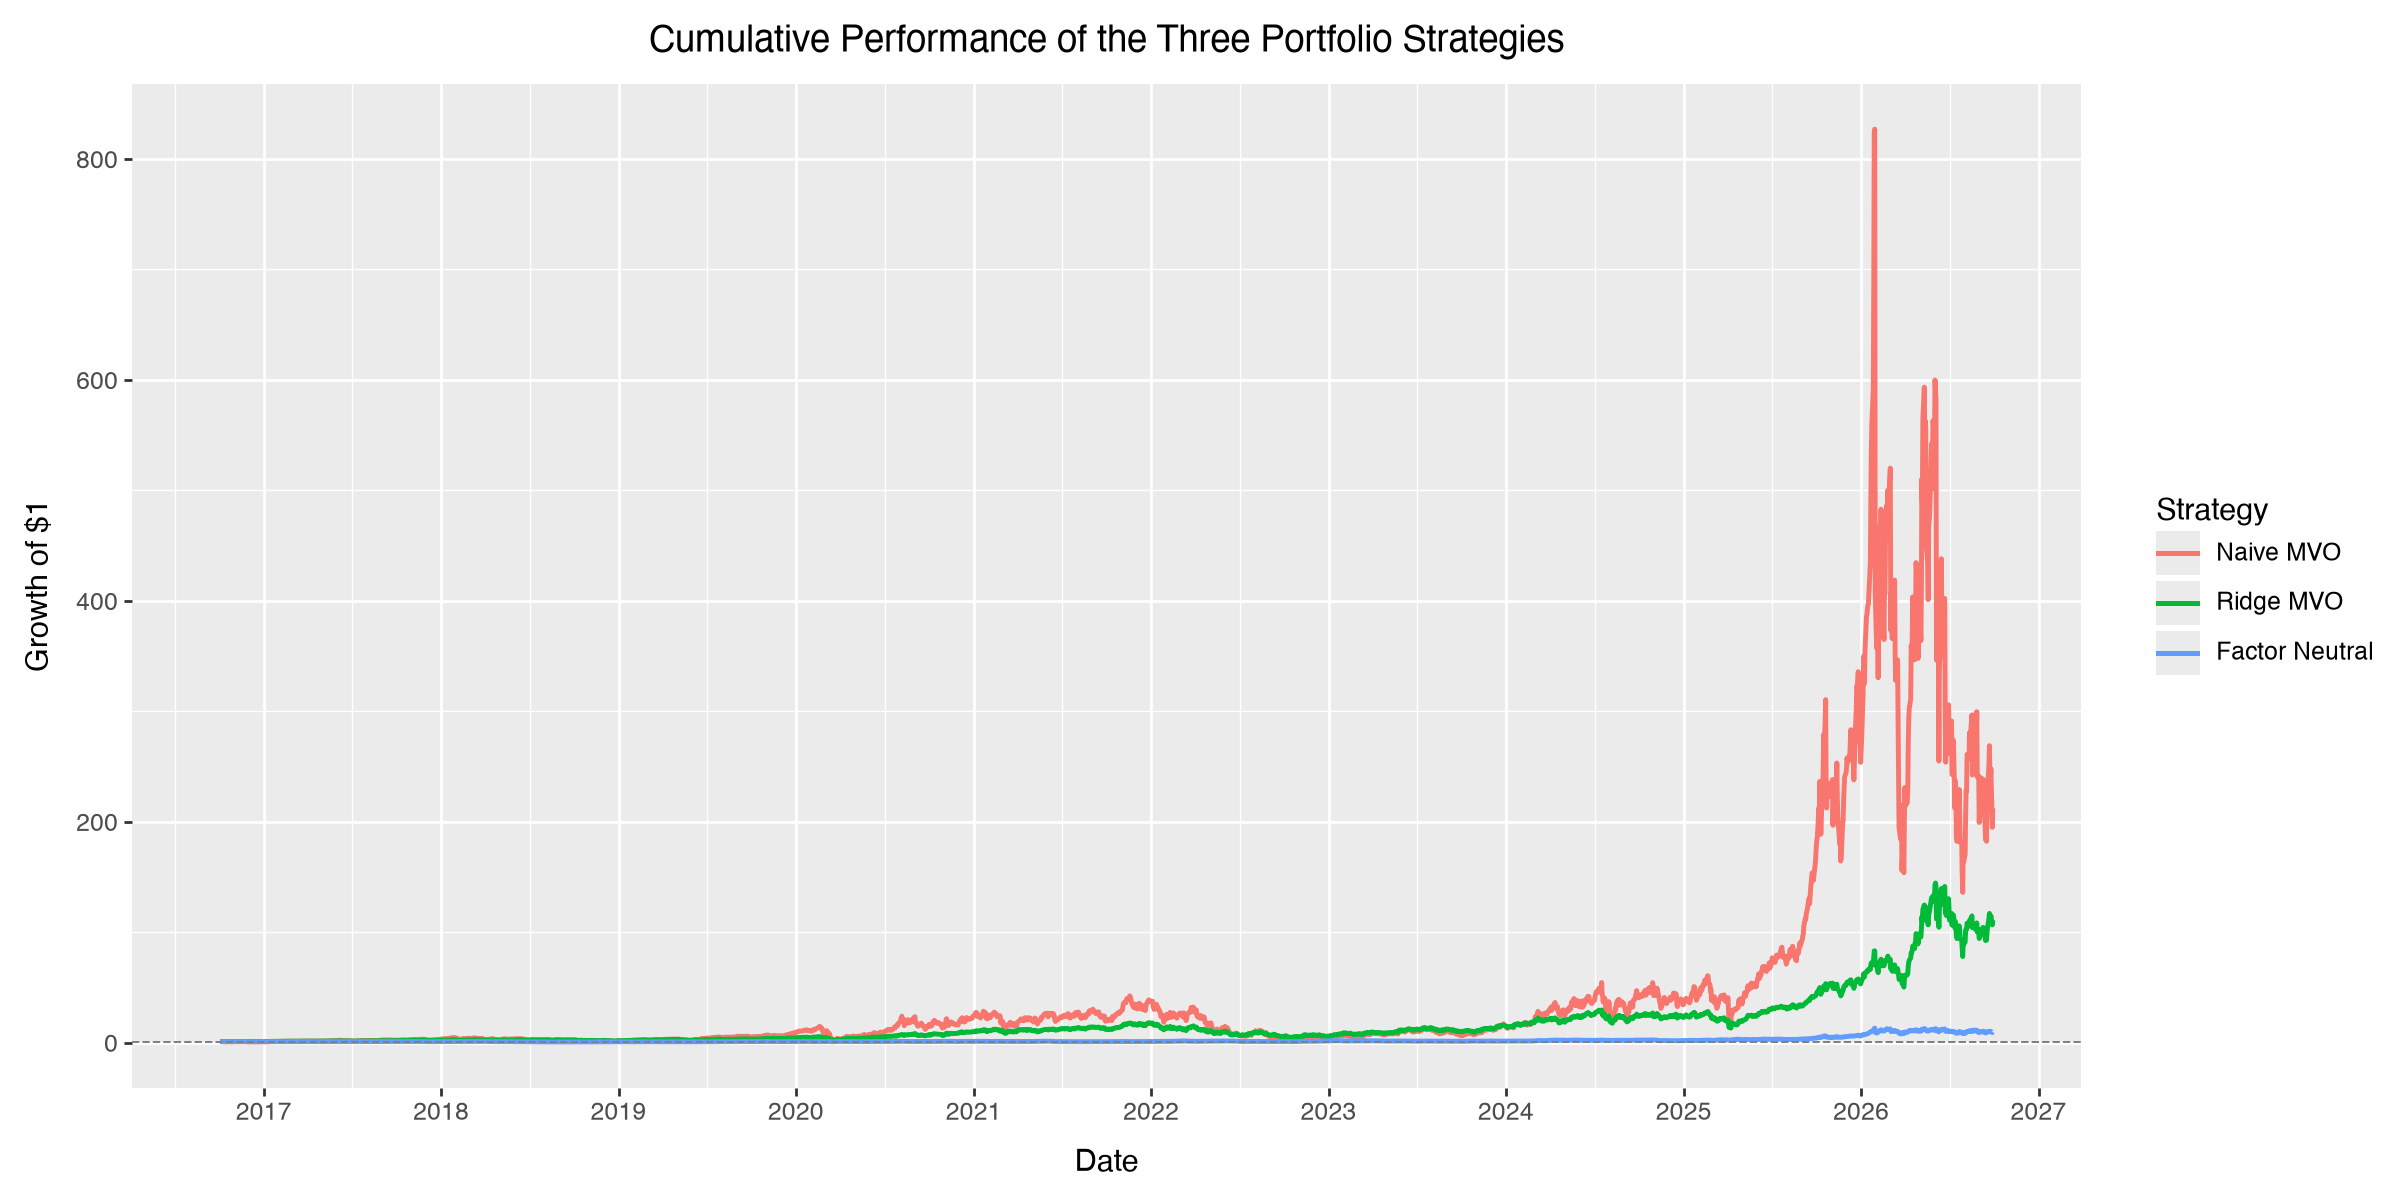

In [57]:
# Daily portfolio returns, rebalanced to the Section 20 weights every day
portfolio_returns = pd.DataFrame(index=R.index)
for strategy in strategy_weights.columns:
    w = strategy_weights[strategy]
    portfolio_returns[strategy] = (
        # add cash on the unused capital
        R @ w + (1 - w.sum()) * rf_daily
    )

# Cumulative growth of $1
equity = (1 + portfolio_returns).cumprod()

# Plot
equity_long = (
    equity
    .rename_axis("Date")
    .reset_index()
    .melt(id_vars="Date", var_name="Strategy", value_name="Growth")
)

# Keep the original strategy order in the legend
equity_long["Strategy"] = pd.Categorical(
    equity_long["Strategy"],
    categories=strategy_weights.columns
)

display(
    ggplot(equity_long, aes("Date", "Growth", color="Strategy"))
    + geom_line(size=1)
    + geom_hline(yintercept=1, color="gray", linetype="dashed", size=0.4)
    + scale_x_date(date_labels="%Y", date_breaks="1 year")
    + labs(
        title="Cumulative Performance of the Three Portfolio Strategies",
        x="Date",
        y="Growth of $1"
    )
    + theme(figure_size=(12, 6))
)

### Two-factor regression fit by strategy

Each chart compares a strategy's cumulative excess return with the part explained by the factors (β_MKT·MKT + β_HML·HML). The gap between the two lines is alpha plus residual noise.

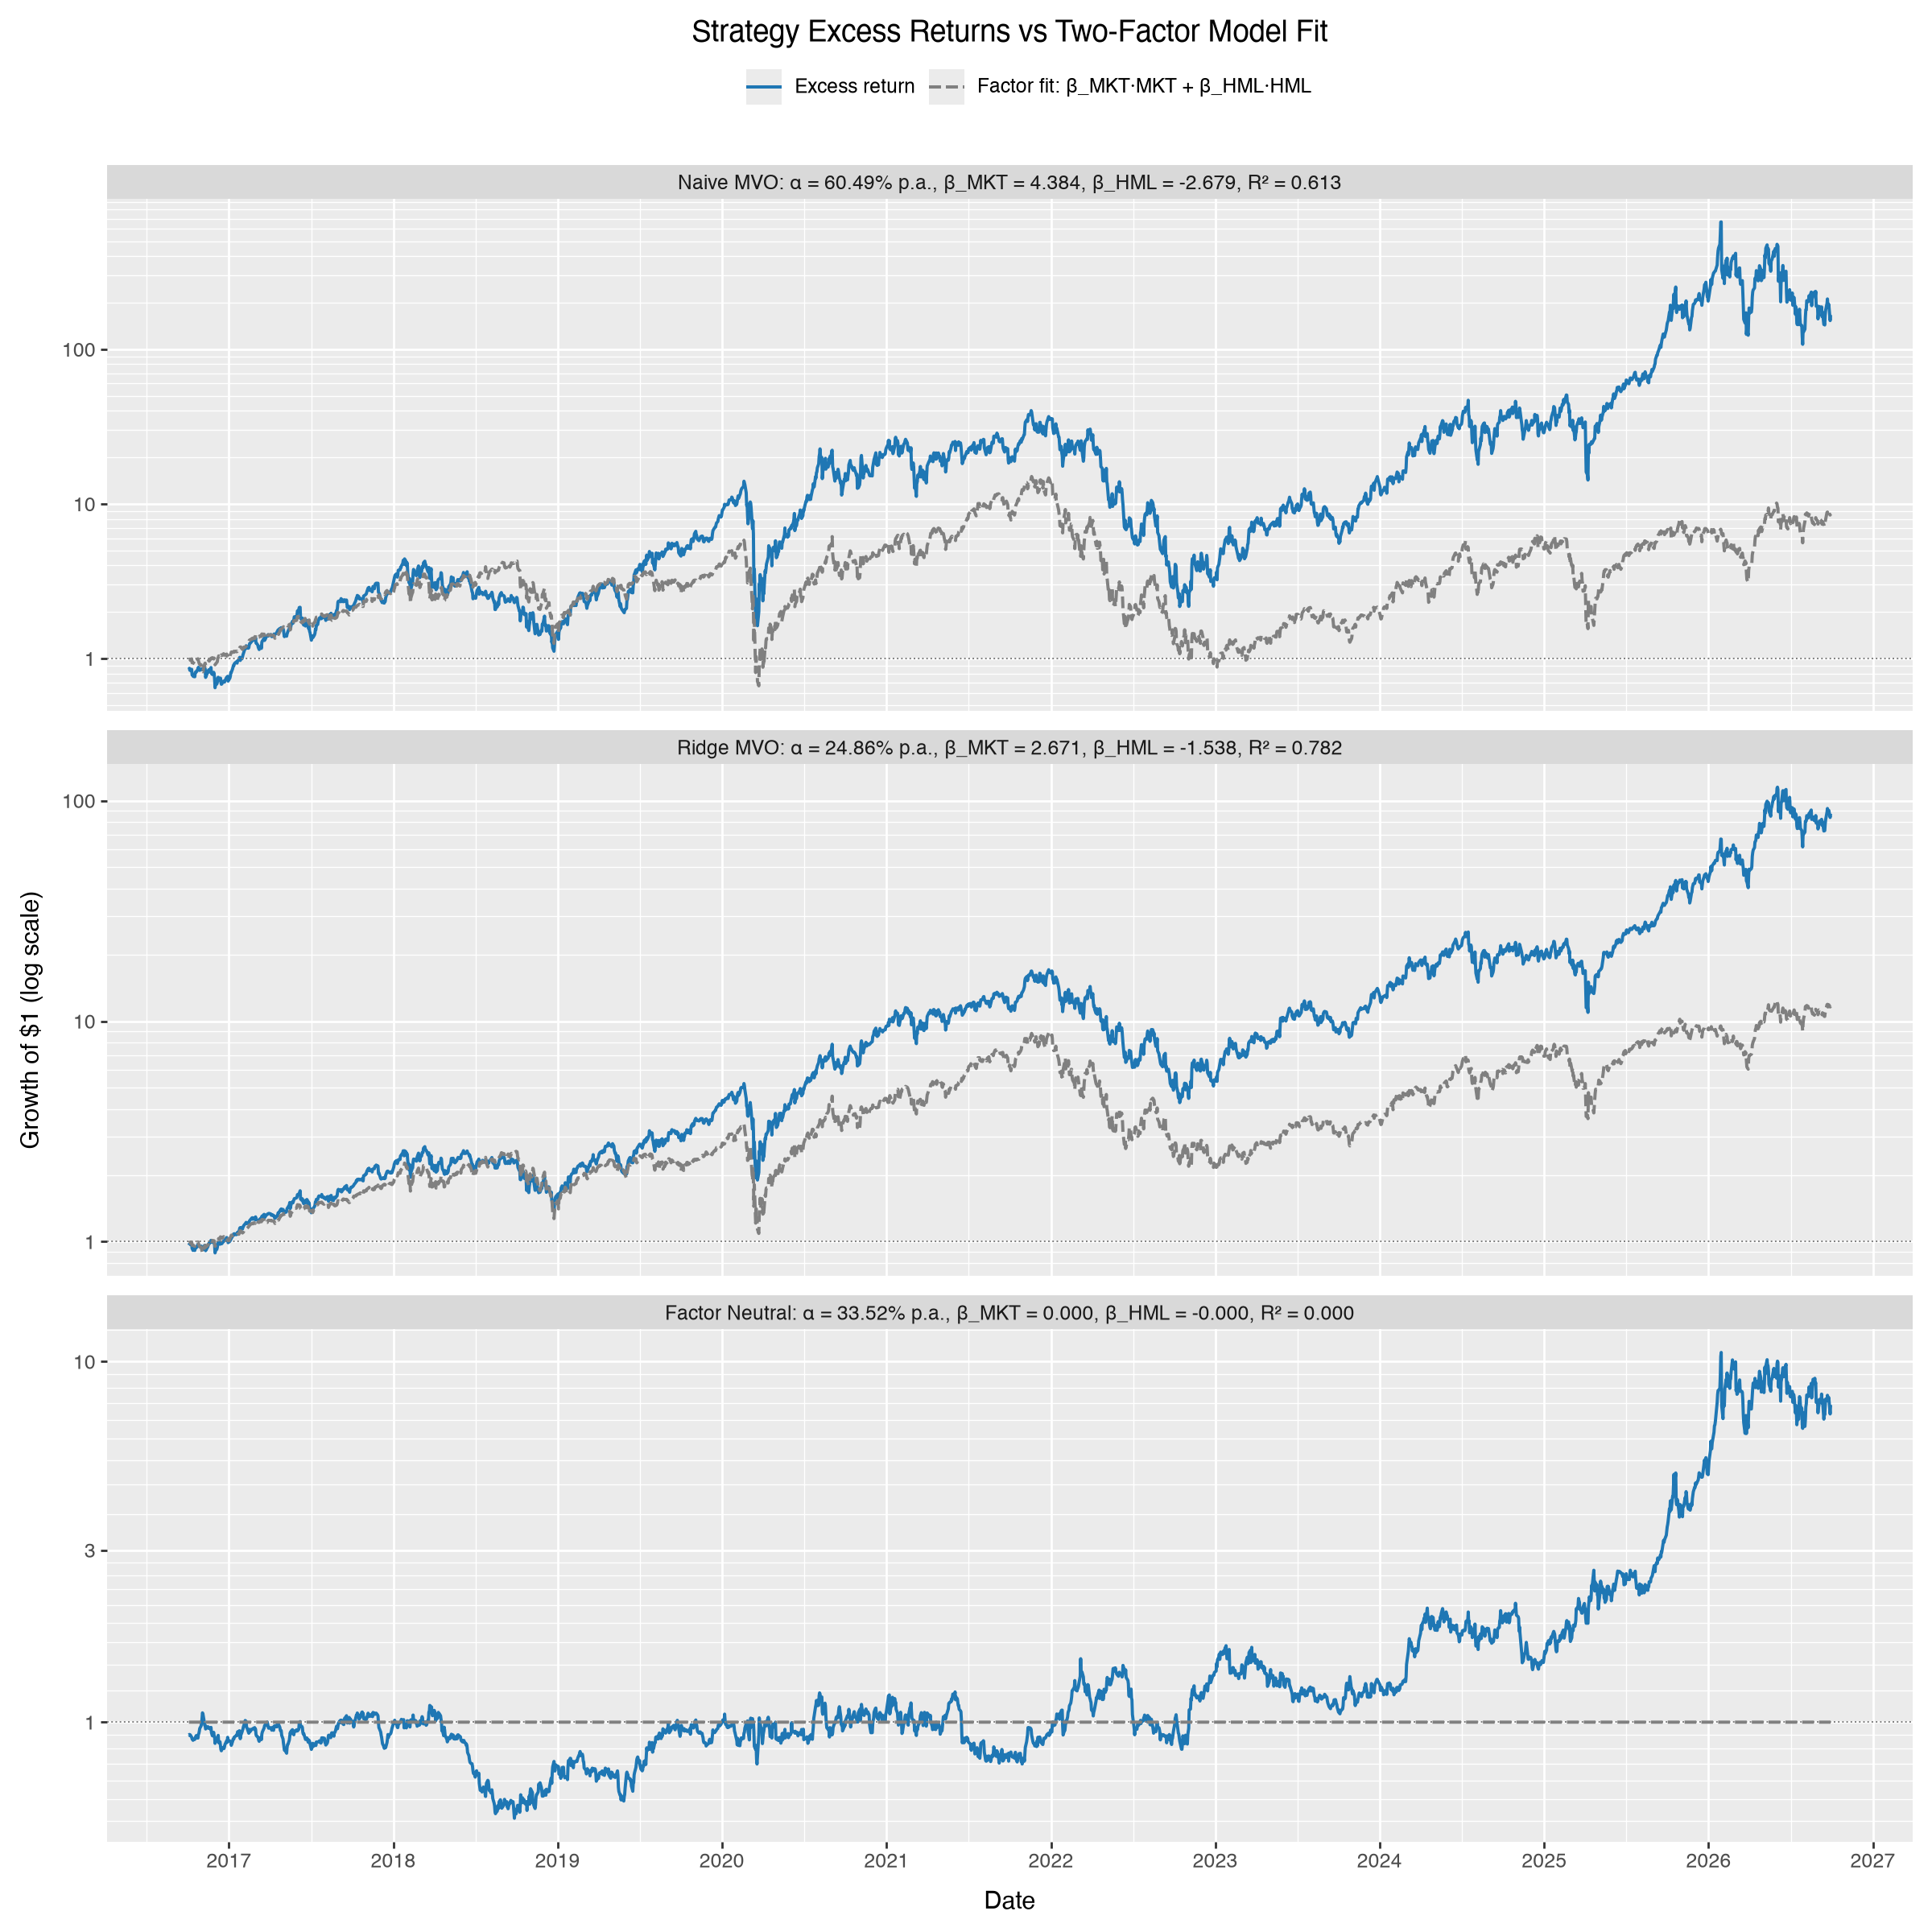

In [58]:
# Regress each strategy's excess return on the two factors:
# Rp - Rf = alpha + beta_MKT*MKT + beta_HML*HML + error
fit_data = pd.concat(
    [
        portfolio_returns,
        F["MKT"],
        F["HML"],
        rf_daily.rename("RF")
    ],
    axis=1
).replace([np.inf, -np.inf], np.nan).dropna()

X_fit = np.column_stack([
    np.ones(len(fit_data)),
    fit_data["MKT"].values,
    fit_data["HML"].values
])

fit_curves = []

for strategy in strategy_weights.columns:

    # Excess portfolio return
    y_fit = (fit_data[strategy] - fit_data["RF"]).values

    # OLS regression
    a_fit, b_mkt, b_hml = np.linalg.lstsq(X_fit, y_fit, rcond=None)[0]

    # Factor-explained return (excludes alpha and residual)
    factor_part = b_mkt * fit_data["MKT"] + b_hml * fit_data["HML"]

    # R-squared
    fitted_fit = a_fit + factor_part.values
    r2_fit = 1 - np.sum((y_fit - fitted_fit) ** 2) / np.sum((y_fit - y_fit.mean()) ** 2)

    # Panel title carries the regression statistics
    panel = (
        f"{strategy}: α = {a_fit * trading_days:.2%} p.a., "
        f"β_MKT = {b_mkt:.3f}, β_HML = {b_hml:.3f}, R² = {r2_fit:.3f}"
    )

    # Cumulative growth of $1
    curves = pd.DataFrame({
        "Excess return": (1 + pd.Series(y_fit, index=fit_data.index)).cumprod(),
        "Factor fit: β_MKT·MKT + β_HML·HML": (1 + factor_part).cumprod()
    })

    curves = (
        curves
        .rename_axis("Date")
        .reset_index()
        .melt(id_vars="Date", var_name="Series", value_name="Growth")
    )
    curves["Strategy"] = panel

    fit_curves.append(curves)

fit_curves = pd.concat(fit_curves)

# Keep the original strategy order for the panels
fit_curves["Strategy"] = pd.Categorical(
    fit_curves["Strategy"],
    categories=fit_curves["Strategy"].unique()
)

# Log scale cannot show a wiped-out (≤ 0) portfolio value
fit_curves = fit_curves[fit_curves["Growth"] > 0]

display(
    ggplot(fit_curves, aes("Date", "Growth", color="Series", linetype="Series"))
    + geom_line(size=0.8)
    + geom_hline(yintercept=1, color="gray", linetype="dotted", size=0.4)
    + facet_wrap("~Strategy", ncol=1, scales="free_y")
    + scale_x_date(date_labels="%Y", date_breaks="1 year")
    + scale_y_log10(labels=lambda values: [f"{v:g}" for v in values])
    + scale_color_manual(values=["#1f77b4", "gray"])
    + scale_linetype_manual(values=["solid", "dashed"])
    + labs(
        title="Strategy Excess Returns vs Two-Factor Model Fit",
        x="Date",
        y="Growth of $1 (log scale)",
        color="",
        linetype=""
    )
    + theme(figure_size=(12, 12), legend_position="top")
)

## 24. CORRELATION HEATMAP

Correlation matrix:


Ticker,GLD,QQQ,SOXX,TLT
Ticker,,,,
GLD,1.000,0.127,0.145,0.244
QQQ,0.127,1.000,0.871,-0.083
SOXX,0.145,0.871,1.000,-0.082
TLT,0.244,-0.083,-0.082,1.000


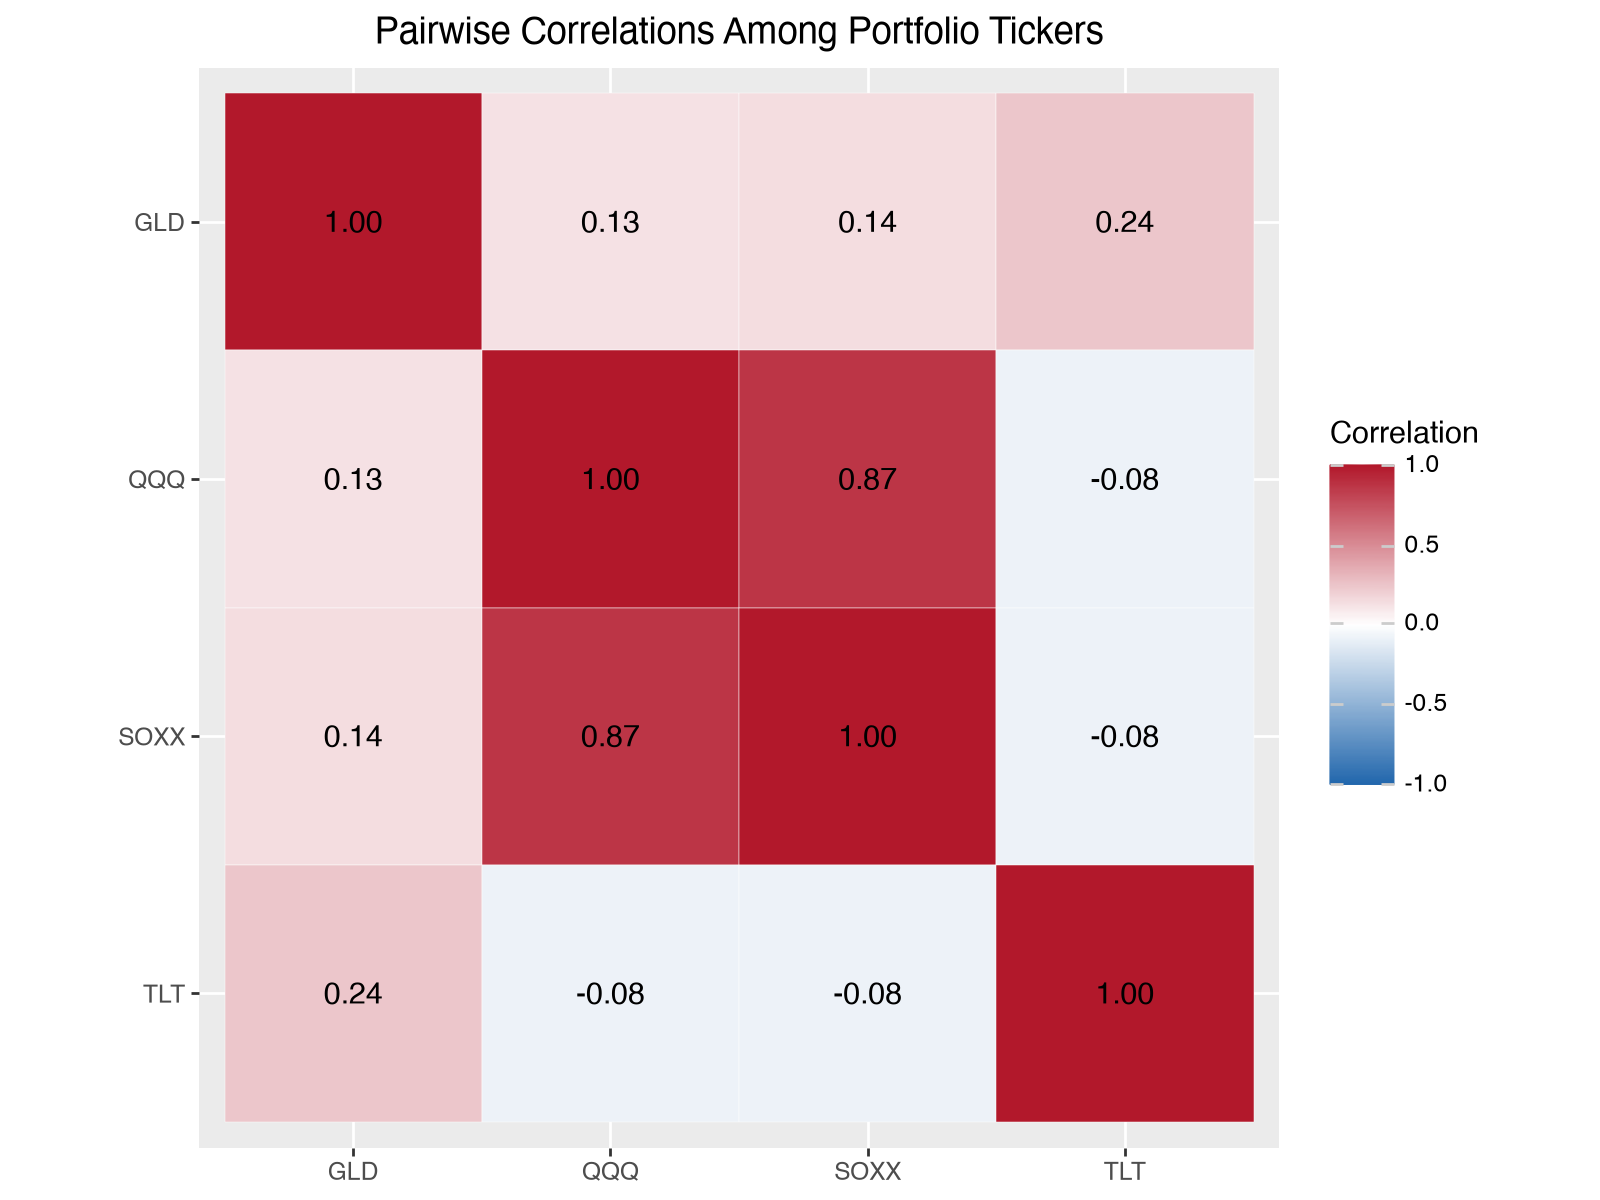

In [59]:
# Daily return correlations among the portfolio tickers
correlation = R[tickers].corr()

print("Correlation matrix:")
display(correlation.round(3))

# Plot heatmap
correlation_long = (
    correlation
    .rename_axis(index="Row", columns="Column")
    .stack()
    .rename("Correlation")
    .reset_index()
)

display(
    ggplot(correlation_long, aes("Column", "Row", fill="Correlation"))
    + geom_tile(color="white")
    + geom_text(aes(label="Correlation"), format_string="{:.2f}")
    + scale_fill_gradient2(
        low="#2166ac",
        mid="white",
        high="#b2182b",
        midpoint=0,
        limits=(-1, 1)
    )
    + scale_x_discrete(limits=tickers)
    + scale_y_discrete(limits=tickers[::-1])
    + coord_equal()
    + labs(
        title="Pairwise Correlations Among Portfolio Tickers",
        x="",
        y=""
    )
    + theme(figure_size=(8, 6))
)

## 25. SUMMARY TABLE

In [60]:
# --------------------------------------------------
# 1. Prepare clean data
# --------------------------------------------------

# Two-factor model
F_two = returns[["MKT", "HML"]].copy()

# Combine everything into one DataFrame
regression_data = pd.concat(
    [
        portfolio_returns,
        F_two,
        rf_daily.rename("RF")
    ],
    axis=1
)

# Replace infinite values with NaN
regression_data = regression_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows with missing values
regression_data = regression_data.dropna()

print(
    "Observations used in regression:",
    len(regression_data)
)


# --------------------------------------------------
# 2. Annualised portfolio return
# --------------------------------------------------

annualised_return = (
    portfolio_returns.mean()
    * trading_days
)


# --------------------------------------------------
# 3. Annualised portfolio volatility
# --------------------------------------------------

annualised_volatility = (
    portfolio_returns.std()
    * np.sqrt(trading_days)
)


# --------------------------------------------------
# 4. Two-factor regression
# --------------------------------------------------
#
# Rp - Rf =
# alpha + beta_MKT*MKT + beta_HML*HML + error
#

X = np.column_stack([
    np.ones(len(regression_data)),
    regression_data["MKT"].values,
    regression_data["HML"].values
])

regression_results = {}

for strategy in portfolio_returns.columns:

    # Excess portfolio return
    y = (
        regression_data[strategy]
        - regression_data["RF"]
    ).values

    # OLS regression
    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    alpha_daily = coefficients[0]
    beta_mkt = coefficients[1]
    beta_hml = coefficients[2]

    # Regression residuals
    residuals = y - X @ coefficients

    # Degrees of freedom
    dof = len(y) - X.shape[1]

    # Residual variance
    residual_variance = (
        residuals @ residuals
    ) / dof

    # Variance-covariance matrix of coefficients
    XTX_inv = np.linalg.inv(X.T @ X)

    # Standard error of alpha
    alpha_se = np.sqrt(
        residual_variance * XTX_inv[0, 0]
    )

    # Alpha t-statistic
    alpha_tstat = (
        alpha_daily / alpha_se
    )

    regression_results[strategy] = {
        "Alpha": alpha_daily,
        "Beta MKT": beta_mkt,
        "Beta HML": beta_hml,
        "Alpha t-stat": alpha_tstat
    }


regression_results = pd.DataFrame(
    regression_results
).T


# --------------------------------------------------
# 5. Annualised alpha
# --------------------------------------------------

annualised_alpha = (
    regression_results["Alpha"]
    * trading_days
)


# --------------------------------------------------
# 6. Tracking Error
# --------------------------------------------------
#
# Benchmark = equal-weight portfolio
#
# TE² = (w - wb)' Σ (w - wb)
#

benchmark_weights = (
    np.ones(len(tickers))
    / len(tickers)
)

tracking_error = {}

for strategy in strategy_weights.columns:

    active_weights = (
        strategy_weights[strategy].values
        - benchmark_weights
    )

    TE_squared = (
        active_weights
        @ Sigma.values
        @ active_weights
    )

    tracking_error[strategy] = np.sqrt(
        TE_squared
    )

tracking_error = pd.Series(
    tracking_error
)


# --------------------------------------------------
# 7. CVaR
# --------------------------------------------------
#
# 95% CVaR = average loss in the worst 5%
# of observed daily portfolio returns.
#

confidence_level = 0.95

cvar = {}

for strategy in portfolio_returns.columns:

    strategy_returns = (
        portfolio_returns[strategy]
        .dropna()
    )

    var_threshold = strategy_returns.quantile(
        1 - confidence_level
    )

    worst_returns = strategy_returns[
        strategy_returns <= var_threshold
    ]

    cvar[strategy] = -worst_returns.mean()


cvar = pd.Series(cvar)


# --------------------------------------------------
# 8. Consolidated summary table
# --------------------------------------------------

summary = pd.DataFrame({

    "Annualised Return":
        annualised_return,

    "Annualised Volatility":
        annualised_volatility,

    "Alpha":
        annualised_alpha,

    "Beta MKT":
        regression_results["Beta MKT"],

    "Beta HML":
        regression_results["Beta HML"],

    "Tracking Error":
        tracking_error,

    "CVaR 95%":
        cvar,

    "Alpha t-stat":
        regression_results["Alpha t-stat"]

})


# --------------------------------------------------
# 9. Display final summary table
# --------------------------------------------------
print("Portfolio weights (rebalanced daily):")
display(strategy_weights.round(4))

print("Portfolio Strategy Comparison")
display(
    summary.style.format({
        "Annualised Return": "{:.2%}",
        "Annualised Volatility": "{:.2%}",
        "Alpha": "{:.2%}",
        "Beta MKT": "{:.3f}",
        "Beta HML": "{:.3f}",
        "Tracking Error": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "Alpha t-stat": "{:.3f}"
    })
)

Observations used in regression: 2508
Portfolio weights (rebalanced daily):


,Naive MVO,Ridge MVO,Factor Neutral
GLD,4.0834,0.9203,2.4128
QQQ,1.8062,0.8703,-2.6881
SOXX,1.6368,1.2603,1.8294
TLT,-0.1425,-0.0636,-0.5542


Portfolio Strategy Comparison


,Annualised Return,Annualised Volatility,Alpha,Beta MKT,Beta HML,Tracking Error,CVaR 95%,Alpha t-stat
Naive MVO,132.47%,123.41%,60.49%,4.384,-2.679,107.95%,18.26%,2.482
Ridge MVO,69.06%,65.70%,24.86%,2.671,-1.538,50.47%,9.61%,2.554
Factor Neutral,35.93%,51.07%,33.52%,0.000,-0.000,51.29%,7.31%,2.068


## Annex

### This part is used to generate the charts to be used for the slide deck.

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---- Colours taken from our Assignment 1 deck (dark theme) ----------
BG, CARD, GRID = "#1A1D1C", "#262A29", "#34504A"
TEXT, MUTED = "#EEF0EF", "#9EA6A3"
MINT, BLUE, ORANGE, YELLOW, GREEN = "#5CC6A7", "#5B8DEF", "#E2692F", "#F0B64A", "#3FA27A"
STRAT_COL = {"Naive MVO": ORANGE, "Ridge MVO": BLUE, "Factor Neutral": MINT}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": "#2E3331", "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.axisbelow": True, "font.size": 12, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.titlecolor": TEXT, "legend.frameon": False,
    "legend.labelcolor": TEXT, "font.family": "DejaVu Sans",
})


def _save(fig, outdir, name):
    path = os.path.join(outdir, name)
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    print("saved", path)


def make_all(ctx, outdir="slide_charts"):
    os.makedirs(outdir, exist_ok=True)
    t = list(ctx["tickers"])
    n = len(t)
    B = pd.DataFrame(np.asarray(ctx["B"], float), index=t, columns=["MKT", "HML"])
    W = pd.DataFrame({"Naive MVO": ctx["w_naive"], "Ridge MVO": ctx["w_ridge"],
                      "Factor Neutral": ctx["w_fn"]}, index=t)
    b = pd.Series(ctx["benchmark"], index=t)
    Sigma, Omega, D = (np.asarray(ctx[k], float) for k in ("Sigma", "Omega", "D"))

    # 1. Correlation heatmap ------------------------------------------------
    corr = pd.DataFrame(ctx["corr"], index=t, columns=t)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    ax.grid(False)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("c", [BLUE, CARD, ORANGE])
    ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
    for i in range(n):
        for j in range(n):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13,
                    fontweight="bold", color=TEXT)
    ax.set_xticks(range(n), t); ax.set_yticks(range(n), t)
    ax.tick_params(length=0, labelsize=12, colors=TEXT)
    for s in ax.spines.values(): s.set_visible(False)
    _save(fig, outdir, "01_correlation.png")

    # 2. Factor loadings B (with R^2) -------------------------------------
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    x = np.arange(n); wbar = 0.36
    for k, (col, c) in enumerate([("MKT", BLUE), ("HML", YELLOW)]):
        vals = B[col].values
        bars = ax.bar(x + (k - 0.5) * wbar, vals, wbar, color=c, label=f"β {col}")
        for bx, v in zip(bars, vals):
            ax.text(bx.get_x() + bx.get_width() / 2, v + (0.04 if v >= 0 else -0.04),
                    f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=10, color=TEXT)
    r2 = ctx.get("R2")
    labels = [f"{tk}\nR² = {r2[tk]:.2f}" if r2 else tk for tk in t]
    ax.set_xticks(x, labels); ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_ylabel("Factor loading (regression slope)")
    ax.set_ylim(min(-1.0, B.values.min() - 0.3), B.values.max() + 0.35)
    ax.legend(loc="upper left", ncol=2)
    _save(fig, outdir, "02_factor_loadings.png")

    # 3. Naive MVO: weights before and after the nudge --------------------
    w0 = pd.Series(ctx["w_naive"], index=t); w1 = pd.Series(ctx["w_nudged"], index=t)
    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    ax.bar(x - 0.19, w0.values, 0.36, color=MUTED, label="Original μ")
    ax.bar(x + 0.19, w1.values, 0.36, color=ORANGE, label=f"μ({ctx['nudged_ticker']}) + 1 pp")
    for i, tk in enumerate(t):
        d = w1[tk] - w0[tk]
        top = max(w0[tk], w1[tk], 0)
        ax.text(i, top + 0.15, f"{d*100:+.0f} pp", ha="center", va="bottom", fontsize=11,
                fontweight="bold", color=ORANGE if tk == ctx["nudged_ticker"] else MUTED)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xticks(x, t); ax.set_ylabel("Portfolio weight")
    ax.set_ylim(min(w0.min(), w1.min()) - 0.4, max(w0.max(), w1.max()) + 0.8)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
    _save(fig, outdir, "03_naive_nudge.png")

    # 4. Ridge: swing, turnover and gross exposure vs eta -----------------
    rr = pd.DataFrame(ctx["ridge"])
    xs = rr["eta"].replace(0, 1e-4)                 # plot eta = 0 at the left edge
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))
    ax = axes[0]
    ax.plot(xs, rr["weight_swing"], "-o", color=ORANGE, label="Weight swing (L2)")
    ax.plot(xs, rr["turnover"], "-o", color=BLUE, label="Turnover")
    ax.set_title("After the +1 pp nudge", loc="left")
    ax2 = axes[1]
    ax2.plot(xs, rr["gross_exposure"], "-o", color=MINT)
    ax2.axhline(1, color=MUTED, lw=0.8, ls="--"); ax2.text(1.2e-4, 1.15, "1× = no leverage", color=MUTED, fontsize=10)
    ax2.set_title("Gross exposure Σ|w|", loc="left")
    sel = ctx["selected_eta"]
    for a in axes:
        a.set_xscale("log"); a.axvline(sel, color=YELLOW, lw=1.2, ls=":")
        ticks = [v for v in rr["eta"].tolist() if v in (0, 0.001, 0.01, 0.1, 1.0)]
        a.set_xticks([max(v, 1e-4) for v in ticks], [f"{v:g}" for v in ticks], fontsize=9)
        a.minorticks_off(); a.set_xlabel("η (ridge penalty)")
    axes[0].text(sel * 1.15, axes[0].get_ylim()[1] * 0.9, f"chosen η = {sel:g}", color=YELLOW, fontsize=10)
    axes[0].legend(loc="lower left")
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}×"))
    fig.tight_layout()
    _save(fig, outdir, "04_ridge_sweep.png")

    # 5. Weights of the three strategies vs the benchmark -----------------
    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    wb = 0.26
    for k, s in enumerate(W.columns):
        bars = ax.bar(x + (k - 1) * wb, W[s].values, wb, color=STRAT_COL[s], label=s)
        for bx, v in zip(bars, W[s].values):
            ax.text(bx.get_x() + bx.get_width() / 2, v + (0.08 if v >= 0 else -0.08), f"{v:.2f}",
                    ha="center", va="bottom" if v >= 0 else "top", fontsize=8.5, color=TEXT)
    ax.scatter(x, b.values, marker="_", s=900, color=TEXT, zorder=5, label="Equal-weight benchmark")
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xticks(x, t); ax.set_ylabel("Weight")
    lo, hi = W.values.min(), W.values.max()
    ax.set_ylim(lo - 0.6, hi + 0.8)
    ax.legend(loc="upper center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.12))
    _save(fig, outdir, "05_weights_compare.png")

    # 6. Factor exposures B'w: the neutrality check ------------------------
    expo = pd.DataFrame({s: B.T.values @ W[s].values for s in W.columns}, index=B.columns)
    expo["Benchmark"] = B.T.values @ b.values
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    cols = list(W.columns) + ["Benchmark"]
    colmap = {**STRAT_COL, "Benchmark": MUTED}
    for k, s in enumerate(cols):
        bars = ax.bar(np.arange(2) + (k - 1.5) * 0.2, expo[s].values, 0.2, color=colmap[s], label=s)
        for bx, v in zip(bars, expo[s].values):
            ax.text(bx.get_x() + bx.get_width() / 2, v + (0.06 if v >= 0 else -0.06),
                    "0.00" if abs(v) < 5e-3 else f"{v:.2f}", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=9, color=TEXT)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_xticks([0, 1], ["Market exposure (β MKT)", "Value exposure (β HML)"])
    ax.set_ylabel("Portfolio exposure Bᵀw")
    ax.set_ylim(expo.values.min() - 0.5, expo.values.max() + 0.6)
    ax.legend(loc="upper right", ncol=2, fontsize=9)
    _save(fig, outdir, "06_factor_exposures.png")

    # 7. Tracking error, split into factor bets and stock-specific bets -----
    rows = []
    for s in W.columns:
        a = W[s].values - b.values
        fac = float((B.T.values @ a) @ Omega @ (B.T.values @ a))
        spec = float(a @ D @ a)
        rows.append((s, fac, spec, float(np.sqrt(a @ Sigma @ a))))
    te = pd.DataFrame(rows, columns=["s", "factor", "specific", "TE"]).set_index("s")
    fig, ax = plt.subplots(figsize=(7.0, 3.2))
    y = np.arange(len(te))[::-1]
    ax.barh(y, te["factor"], color=ORANGE, label="Factor bets  (Bᵀa)ᵀΩ(Bᵀa)")
    ax.barh(y, te["specific"], left=te["factor"], color=BLUE, label="Stock-specific  aᵀDa")
    for yy, (s, r) in zip(y, te.iterrows()):
        ax.text(r["factor"] + r["specific"] + 0.01, yy, f"TE = {r['TE']:.1%}", va="center",
                fontsize=11, fontweight="bold", color=STRAT_COL[s])
    ax.set_yticks(y, te.index); ax.tick_params(axis="y", colors=TEXT, labelsize=11)
    ax.set_xlabel("TE² = aᵀΣa  (annualised variance, a = w − b)")
    ax.set_xlim(0, (te["factor"] + te["specific"]).max() * 1.32)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(axis="y", visible=False)
    _save(fig, outdir, "07_tracking_error.png")

    # 8. Growth of $1 (needs the price data, so only runs inside the notebook)
    if ctx.get("R") is not None:
        R = ctx["R"][t]
        rf = ctx.get("rf_daily")
        rf = rf.reindex(R.index).fillna(0) if rf is not None else 0.0
        # any capital not in the ETFs (1 - sum of weights) earns / pays the daily T-bill rate
        rets = pd.DataFrame({s: R @ W[s] + (1 - W[s].sum()) * rf for s in W.columns})
        rets["Equal weight"] = R @ b
        eq = (1 + rets).cumprod()
        fig, ax = plt.subplots(figsize=(9.4, 3.9))
        for s in rets.columns:
            ax.plot(eq.index, eq[s], color=STRAT_COL.get(s, MUTED), lw=1.6 if s in STRAT_COL else 1.2,
                    ls="-" if s in STRAT_COL else "--", label=f"{s}  (${eq[s].iloc[-1]:,.1f})")
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:g}"))
        ax.set_ylabel("Growth of $1 (log scale)")
        ax.legend(loc="upper left", fontsize=10)
        _save(fig, outdir, "08_growth_of_1.png")
        dd = (eq / eq.cummax() - 1).min()
        ctx["_max_drawdown"] = dd.to_dict()
        ctx["_final_value"] = eq.iloc[-1].to_dict()

    # Numbers for the slides ---------------------------------------------------
    out = {"weights": W.round(4).to_dict(), "exposures": expo.round(4).to_dict(),
           "TE": te.round(4).to_dict(), "gross": W.abs().sum().round(3).to_dict(),
           "max_drawdown": ctx.get("_max_drawdown"), "final_value": ctx.get("_final_value")}
    with open(os.path.join(outdir, "slide_numbers.json"), "w") as f:
        json.dump(out, f, indent=1, default=float)
    print("\nNumbers for the slides:\n", json.dumps(out, indent=1, default=float))


# ---- Run inside the notebook: map the notebook's variables ------------------
if "w_naive" in globals():
    make_all({
        "tickers": tickers,
        "corr": R[tickers].corr().values,
        "B": B[["MKT", "HML"]].values,
        "R2": {k: v["R²"] for k, v in regression_stats.items()},
        "w_naive": w_naive.values,
        "w_nudged": w_naive_nudged.values,
        "nudged_ticker": "QQQ",
        "ridge": ridge_results[["eta", "weight_swing", "turnover", "gross_exposure"]],
        "selected_eta": selected_eta,
        "w_ridge": w_ridge.values,
        "w_fn": w_fn.values,
        "benchmark": benchmark_weights,
        "Sigma": Sigma_np, "Omega": np.asarray(Omega), "D": np.asarray(D),
        "R": R,
        "rf_daily": rf_daily,
    })


saved slide_charts/01_correlation.png
saved slide_charts/02_factor_loadings.png
saved slide_charts/03_naive_nudge.png
saved slide_charts/04_ridge_sweep.png
saved slide_charts/05_weights_compare.png
saved slide_charts/06_factor_exposures.png
saved slide_charts/07_tracking_error.png
saved slide_charts/08_growth_of_1.png

Numbers for the slides:
 {
 "weights": {
  "Naive MVO": {
   "GLD": 4.0834,
   "QQQ": 1.8062,
   "SOXX": 1.6368,
   "TLT": -0.1425
  },
  "Ridge MVO": {
   "GLD": 0.9203,
   "QQQ": 0.8703,
   "SOXX": 1.2603,
   "TLT": -0.0636
  },
  "Factor Neutral": {
   "GLD": 2.4128,
   "QQQ": -2.6881,
   "SOXX": 1.8294,
   "TLT": -0.5542
  }
 },
 "exposures": {
  "Naive MVO": {
   "MKT": 4.3839,
   "HML": -2.679
  },
  "Ridge MVO": {
   "MKT": 2.6711,
   "HML": -1.5376
  },
  "Factor Neutral": {
   "MKT": 0.0,
   "HML": -0.0
  },
  "Benchmark": {
   "MKT": 0.5712,
   "HML": -0.4046
  }
 },
 "TE": {
  "factor": {
   "Naive MVO": 0.6985,
   "Ridge MVO": 0.2032,
   "Factor Neutral": 0.0